In [1]:
# /mnt/lab_data2/anusri/MotifCompendium/get_motif_string_final.ipynb - read annotated motif compendium object and generate csv with annotations
# marginal_footprinting_distances.py on csv file
# use this file to get basic anlaysis but you dont really need this, directly plot with /mnt/lab_data2/anusri/MotifCompendium/get_composite_motif_profiles.ipynb

import h5py
import numpy as np

def load_dict_from_h5(h5group):
    dic = {}
    for key, item in h5group.items():
        if isinstance(item, h5py.Group):
            # If subgroup looks like a list (all keys are integers)
            if all(k.isdigit() for k in item.keys()):
                lst = [item[str(i)][()] for i in sorted(map(int, item.keys()))]
                dic[key] = lst
            else:
                dic[key] = load_dict_from_h5(item)
        elif isinstance(item, h5py.Dataset):
            dic[key] = item[()]
    return dic

# Function to load the whole dictionary from HDF5 file
def load_from_h5(filename):
    with h5py.File(filename, 'r') as h5file:
        return load_dict_from_h5(h5file)



In [2]:
h5file="/mnt/lab_data2/anusri/chrombpnet/src/evaluation/marginal_footprints/composite_footprint_data.h5"
loaded_data = load_from_h5(h5file)

h5file="/mnt/lab_data2/anusri/chrombpnet/src/evaluation/marginal_footprints/composite_footprint_data_rev.h5"
loaded_data_rev = load_from_h5(h5file)


In [3]:
import pandas as pd
motif_table_orig = pd.read_csv("/mnt/lab_data2/anusri/chrombpnet/src/evaluation/marginal_footprints/composites_summary_table_2.tsv", sep='\t', header=0)
motif_table = pd.read_csv("/mnt/lab_data2/anusri/chrombpnet/src/evaluation/marginal_footprints/composites_summary_table_2.tsv", sep='\t', header=0)
motif_table=motif_table[~(motif_table["Annotation"]=="Remove")]
print(motif_table.shape)
celltype = motif_table['model'].str.split("_", expand=True)[0]
motif_table["cell_type"] = celltype
#motif_table = motif_table[motif_table['posneg']=="pos"]

(64, 34)


In [4]:
motif_table.shape

(64, 35)

In [5]:
# number of unique composite motifs
motif_table["cluster"].nunique()

58

In [6]:
celltype.value_counts()

GM12878    20
HEPG2      12
H1ESC      12
IMR90      12
K562        8
Name: 0, dtype: int64

In [7]:
unique_clusters_per_celltype = motif_table.groupby('cell_type')['cluster'].nunique()
unique_clusters_per_celltype

cell_type
GM12878    19
H1ESC      11
HEPG2      10
IMR90      11
K562        8
Name: cluster, dtype: int64

In [8]:
import numpy as np
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import fdrcorrection


def find_synergy(joine, combined):

    #print(joine)
    # Assuming delta_J and delta_S are your list of values
    flattened_values = np.concatenate([np.array(val).flatten() for val in joine])
    delta_J = np.abs(flattened_values)  # Replace with your actual values
    #delta_J = flattened_values  # Replace with your actual values

    flattened_values = np.concatenate([np.array(val).flatten() for val in combined])
    delta_S = np.abs(flattened_values) # Replace with your actual values
    #delta_S = flattened_values # Replace with your actual values

    # Calculate the difference between ΔJ and ΔS
    diff = np.array(delta_J) - np.array(delta_S)

    # Perform the Wilcoxon signed-rank test
    stat, p_values = wilcoxon(diff)

    # Adjust p-values using the Benjamini-Hochberg method
    adjusted_p_values = fdrcorrection(p_values, alpha=0.001)[1]

    # Determine which motif pairs are annotated as synergistic
    synergistic_motifs = (adjusted_p_values < 0.001) & (diff > 0.10)
    
    return synergistic_motifs, adjusted_p_values, p_values, stat


# get the combine counts and the sum of counts for each pair of motifs
import numpy as np
combined = []
joine = []
for i,r in motif_table.iterrows():
    motifA = np.log(loaded_data[r["name_x"]]['motif1']['counts']) - np.log(loaded_data[r["name_x"]]['control']['counts'])
    motifB = np.log(loaded_data[r["name_x"]]['motif2']['counts']) - np.log(loaded_data[r["name_x"]]['control']['counts'])
    combine_counts_values = loaded_data[r["name_x"]]['combine_counts'].values()
    flattened_values = np.concatenate([np.array(val).flatten() for val in combine_counts_values])
    #print(combine_counts_values)
    joint = np.log(np.max(flattened_values)) - np.log(loaded_data[r["name_x"]]['control']['counts'])
    combined.append(motifA+motifB)
    joine.append(joint)


combined_rev = []
joine_rev = []
for i,r in motif_table.iterrows():
    motifA = np.log(loaded_data_rev[r["name_x"]]['motif1']['counts']) - np.log(loaded_data_rev[r["name_x"]]['control']['counts'])
    motifB = np.log(loaded_data_rev[r["name_x"]]['motif2']['counts']) - np.log(loaded_data_rev[r["name_x"]]['control']['counts'])
    combine_counts_values = loaded_data_rev[r["name_x"]]['combine_counts'].values()
    flattened_values = np.concatenate([np.array(val).flatten() for val in combine_counts_values])
    #print(combine_counts_values)
    joint = np.log(np.max(flattened_values)) - np.log(loaded_data_rev[r["name_x"]]['control']['counts'])
    combined_rev.append(motifA+motifB)
    joine_rev.append(joint)

In [9]:
synergistic_motifs, adjusted_p_values, p_values, stat = find_synergy(joine, combined)
synergistic_motifs_rev, adjusted_p_values_rev, p_values_rev, stat_rev = find_synergy(joine_rev, combined_rev)

In [15]:
# # Print results
# print(f"Wilcoxon test statistic: {stat}")
# print(f"Original p-values: {p_values}")
# print(f"Adjusted p-values: {adjusted_p_values}")
# print(f"Synergistic motifs: {synergistic_motifs}")

In [16]:
motif_table["synergy"] = (synergistic_motifs | synergistic_motifs_rev)


In [17]:
sum(motif_table["synergy"])

35

In [18]:
motif_table[motif_table["synergy"]]["cluster"].nunique()

30

In [52]:
motif_names=[]
for i,r in motif_table.iterrows():
    motif_names.append(r['name_x'])
syn_motif_names = np.array(motif_names)[(synergistic_motifs | synergistic_motifs_rev)]

def find_hard_syntax_motifs(loaded_data_temp, distances):
    #for i,r in motif_table.iterrows(): 
    delta_J = []
    delta_S = []
    arrangements = []


    for keyd in syn_motif_names:
        values = []
        ind_values = []

        motifA = np.log(loaded_data_temp[keyd]['motif1']['counts']) - np.log(loaded_data_temp[keyd]['control']['counts'])
        motifB = np.log(loaded_data_temp[keyd]['motif2']['counts']) - np.log(loaded_data_temp[keyd]['control']['counts'])
        for dist in distances:
            values.append(np.log(loaded_data_temp[keyd]['combine_counts'][str(dist)]) - np.log(loaded_data_temp[keyd]['control']['counts']))
            ind_values.append(motifA+motifB)

        delta_J.append(np.abs(values))
        delta_S.append(np.abs(ind_values))
        arrangements.append(distances)

    # First, calculate Z-scores for joint effects ΔJ for each composite motif
    z_scores = []
    for joint_effects in delta_J:
        
        mean_J = np.mean(joint_effects)
        std_J = np.std(joint_effects)
        z_score = (joint_effects - mean_J) / std_J
        #print(z_score)
        z_scores.append(z_score)

    # Identify hard syntax motifs (Z-score > 4)
    hard_syntax_motifs = [np.any(np.abs(z_score) > 4) for z_score in z_scores]
    
    # Identify soft syntax motifs ((ΔJ - ΔS) > 0.15 at distances between 20 and 150 bp)
    soft_syntax_motifs = []
    for i, joint_effects in enumerate(delta_J):
        independent_effects = delta_S[i]
        distances = arrangements[i]
        soft_syntax = any((joint_effects[j] - independent_effects[j]) > 0.10 and 20 <= abs(distances[j]) <= 150 for j in range(len(distances)))
        soft_syntax_motifs.append(soft_syntax)
    
    return soft_syntax_motifs, hard_syntax_motifs


In [53]:
import numpy as np

# get distances and arrange them
distances = []
motif_names=[]
for i,r in motif_table.iterrows():
    #print(loaded_data[r["name_x"]]['combine_counts'].keys())
    for key in loaded_data[r["name_x"]]['combine_counts'].keys():
        distances.append(int(key))
    break
distances=sorted(distances)

soft_syntax_motifs, hard_syntax_motifs = find_hard_syntax_motifs(loaded_data, distances)
soft_syntax_motifs_rev, hard_syntax_motifs_rev = find_hard_syntax_motifs(loaded_data_rev, distances)

In [22]:
motif_table["hard_syntax"] = False
motif_table.loc[motif_table["synergy"], "hard_syntax"] = (np.array(hard_syntax_motifs) | np.array(hard_syntax_motifs_rev))

In [23]:
sum(motif_table["hard_syntax"])

12

In [32]:
motif_table[motif_table["hard_syntax"]]["cluster"].nunique()

10

In [33]:
hardclust=[]
hardmotifs=[]
for i, r in motif_table[motif_table["hard_syntax"]].iterrows():
    if r["cluster"] in hardclust:
        continue
    hardclust.append(r["cluster"])
    hardmotifs.append(r["name_x"])

In [34]:
hardmotifs

['HEPG2_counts-pos.pattern_26',
 'HEPG2_counts-pos.pattern_34',
 'IMR90_counts-pos.pattern_34',
 'H1ESC_profile-pos.pattern_35',
 'GM12878_counts-pos.pattern_26',
 'HEPG2_profile-pos.pattern_16',
 'IMR90_profile-pos.pattern_59',
 'K562_profile-pos.pattern_24',
 'HEPG2_profile-pos.pattern_58',
 'IMR90_profile-pos.pattern_42']

HEPG2_counts-pos.pattern_26


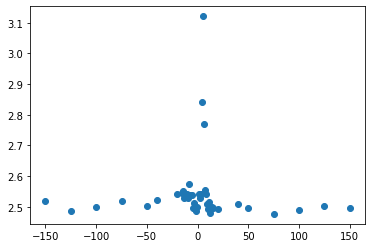

HEPG2_counts-pos.pattern_34


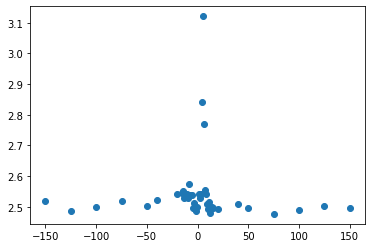

IMR90_counts-pos.pattern_34


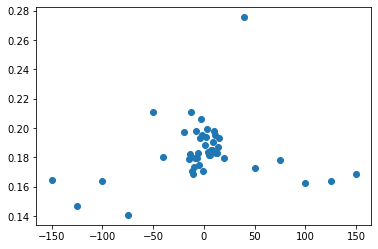

H1ESC_profile-pos.pattern_35


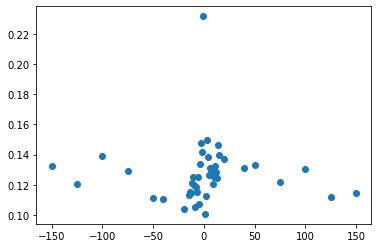

GM12878_counts-pos.pattern_26


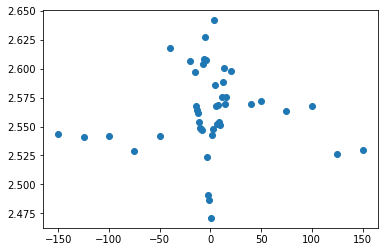

HEPG2_profile-pos.pattern_16


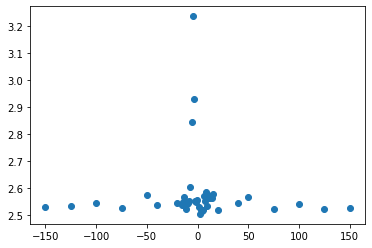

IMR90_profile-pos.pattern_59


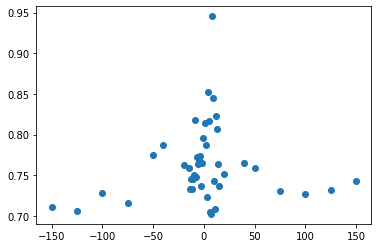

K562_profile-pos.pattern_24


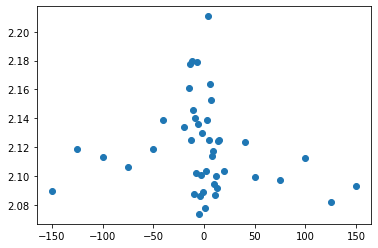

HEPG2_profile-pos.pattern_58


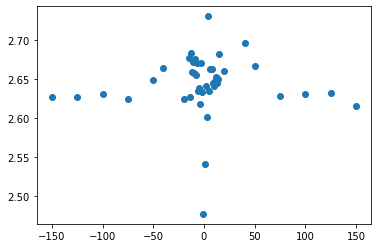

IMR90_profile-pos.pattern_42


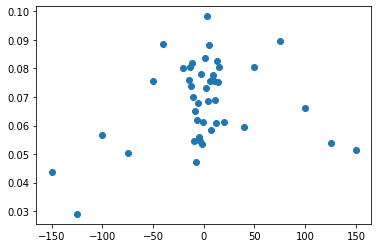

In [35]:
import matplotlib.pyplot as plt
indexes = []
for keyd in hardmotifs:
    flattened_values = []
    for dist in distances:
        flattened_values.append(np.log(loaded_data_rev[keyd]['combine_counts'][str(dist)]) - np.log(loaded_data[r["name_x"]]['control']['counts']))
    print(keyd)
    indexes.append(motif_table_orig[motif_table_orig['name_x']==keyd].index[0])
    joint = np.array(flattened_values)
    plt.figure()
    plt.scatter(distances,joint)
    plt.show()

In [36]:
print(indexes)

[2, 5, 10, 20, 33, 34, 55, 59, 64, 65]


In [37]:
softclust=[]
softmotifs=[]
for i, r in motif_table[(motif_table['synergy'] & ~motif_table['hard_syntax'])].iterrows():
    if r["cluster"] in softclust:
        continue
    softclust.append(r["cluster"])
    softmotifs.append(r["name_x"])

In [38]:
len(softmotifs)

22

GM12878_counts-pos.pattern_37


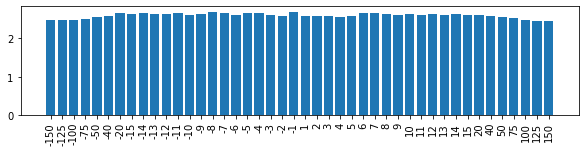

H1ESC_profile-pos.pattern_32


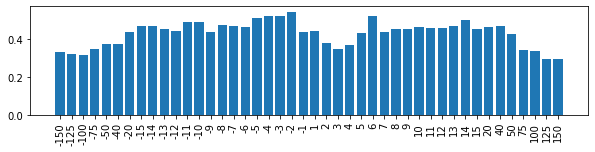

IMR90_profile-pos.pattern_23


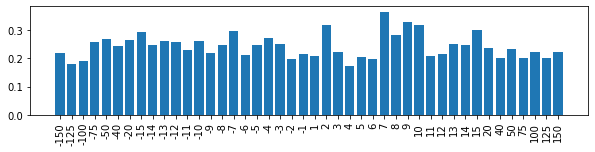

GM12878_profile-pos.pattern_24


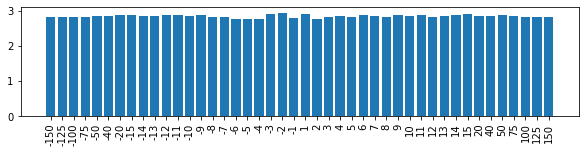

H1ESC_counts-pos.pattern_26


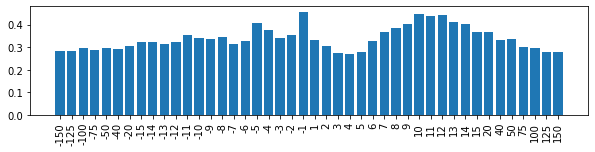

IMR90_counts-pos.pattern_41


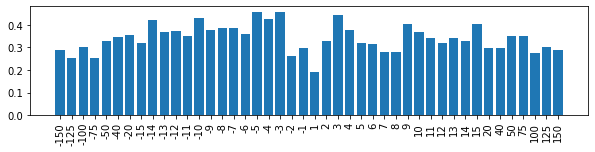

GM12878_profile-pos.pattern_34


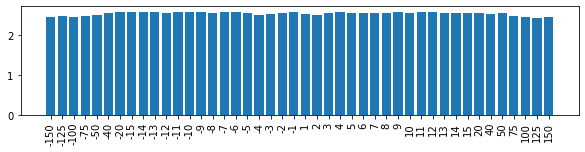

GM12878_counts-pos.pattern_36


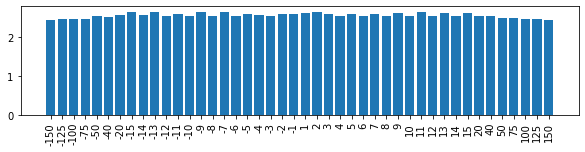

H1ESC_profile-pos.pattern_34


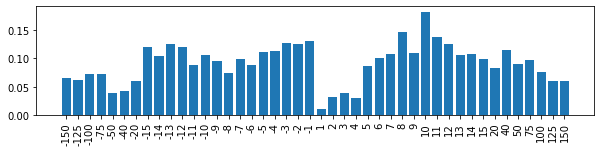

IMR90_profile-pos.pattern_61


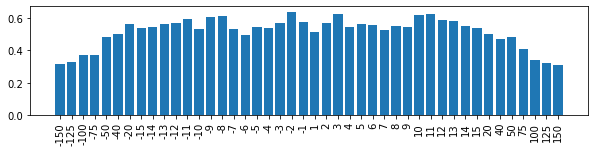

GM12878_profile-pos.pattern_43


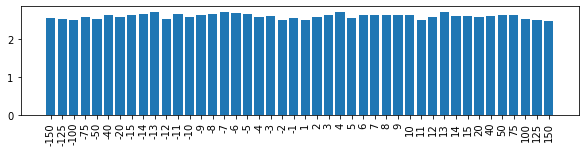

H1ESC_counts-pos.pattern_30


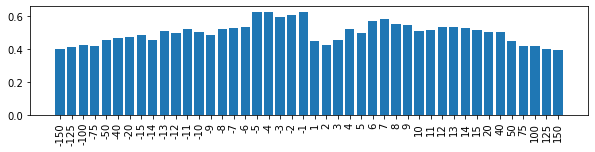

IMR90_profile-pos.pattern_30


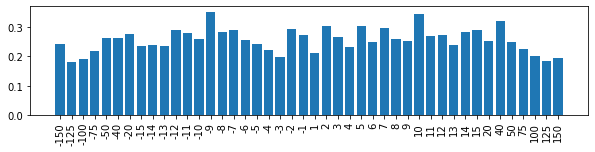

IMR90_profile-pos.pattern_34


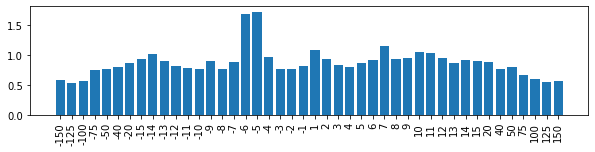

GM12878_counts-pos.pattern_38


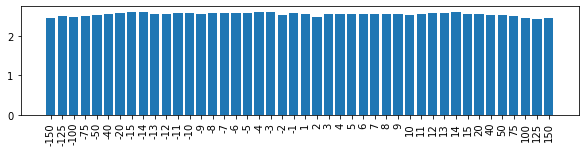

GM12878_counts-pos.pattern_23


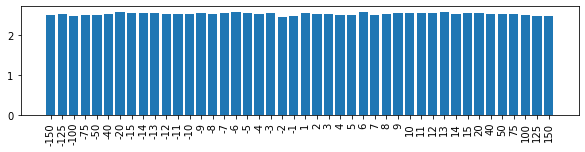

K562_profile-pos.pattern_49


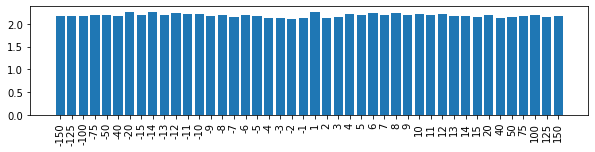

GM12878_profile-pos.pattern_25


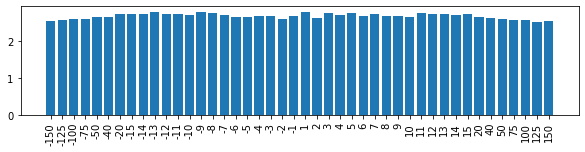

GM12878_profile-neg.pattern_48


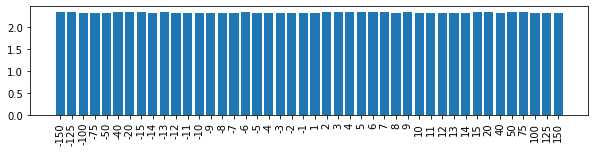

GM12878_profile-pos.pattern_54


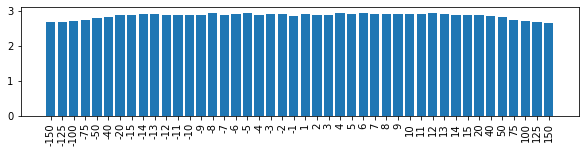

K562_profile-pos.pattern_48


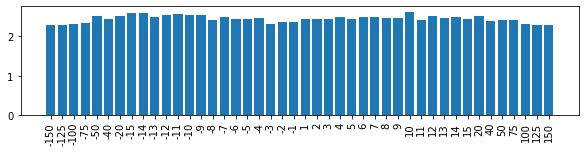

IMR90_profile-pos.pattern_56


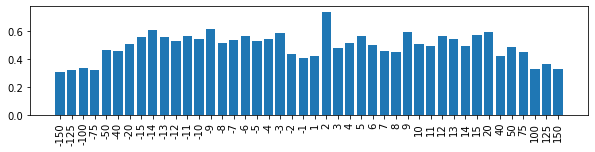

In [31]:
import matplotlib.pyplot as plt
indexes = []
for keyd in softmotifs:
    flattened_values = []
    for dist in distances:
        flattened_values.append(np.log(loaded_data[keyd]['combine_counts'][str(dist)]) - np.log(loaded_data[r["name_x"]]['control']['counts']))
    print(keyd)
    indexes.append(motif_table_orig[motif_table_orig['name_x']==keyd].index[0])
    joint = np.array(flattened_values)
    plt.figure(figsize=(10,2))
    plt.bar(range(len(distances)), joint[:,0], width=0.8)  # Using distances directly as x categories
    plt.xticks(range(len(distances)), distances, rotation=90, ha="center")  # Label x-axis with distances
    plt.show()

In [41]:
#motif_table.to_csv("composite_motifs")
motif_table.to_csv("composite_moitfs_synergy_annotated_table.csv", index=False, sep=',')

In [173]:
indexes

[2, 4, 5, 10, 12, 13, 18, 20, 21, 33, 34, 44, 47, 49, 50, 54, 55, 59, 65]

HEPG2_counts-pos.pattern_26


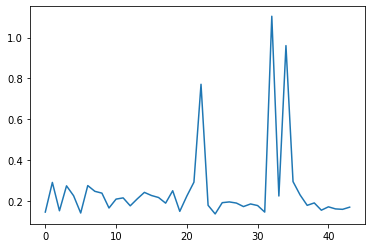

HEPG2_profile-pos.pattern_33


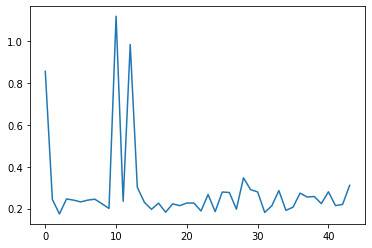

HEPG2_counts-pos.pattern_34


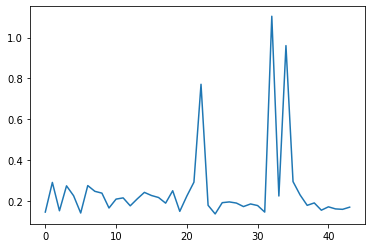

GM12878_counts-pos.pattern_37


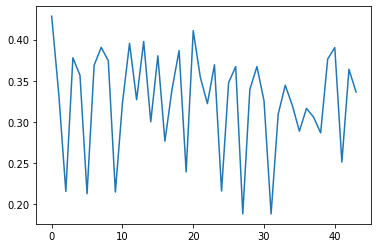

H1ESC_profile-pos.pattern_32


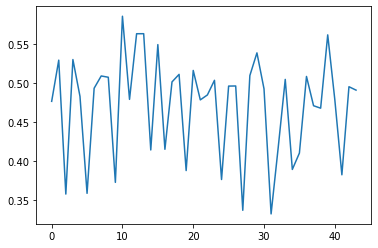

IMR90_counts-pos.pattern_34


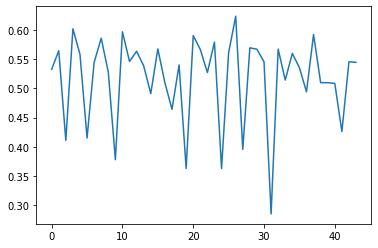

GM12878_profile-pos.pattern_24


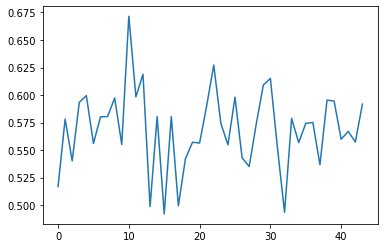

IMR90_counts-pos.pattern_41


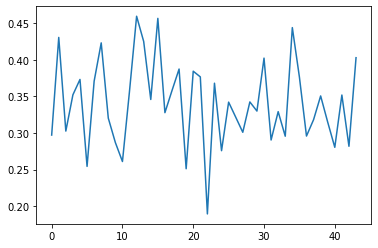

GM12878_profile-pos.pattern_34


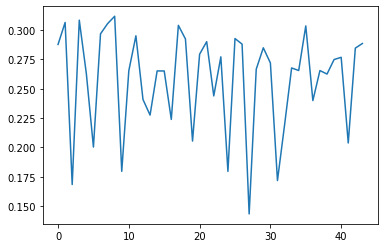

HEPG2_profile-pos.pattern_40


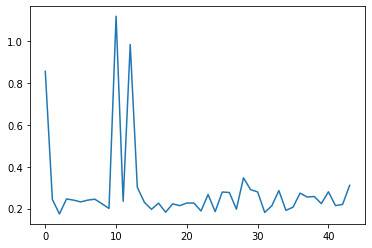

GM12878_counts-pos.pattern_36


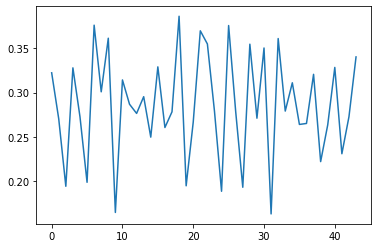

GM12878_counts-pos.pattern_26


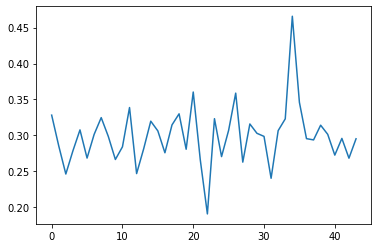

HEPG2_profile-pos.pattern_16


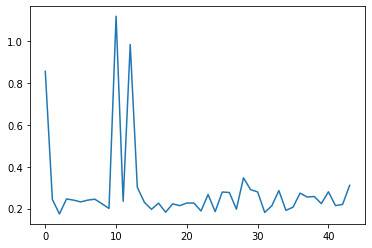

IMR90_profile-pos.pattern_61


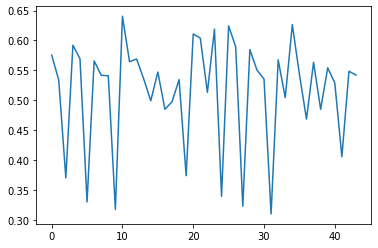

GM12878_profile-pos.pattern_43


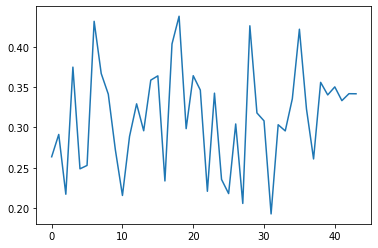

IMR90_profile-pos.pattern_30


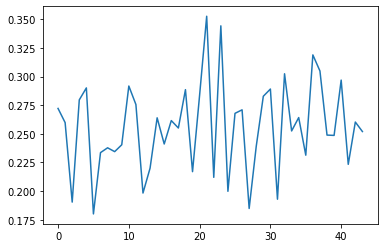

IMR90_profile-pos.pattern_34


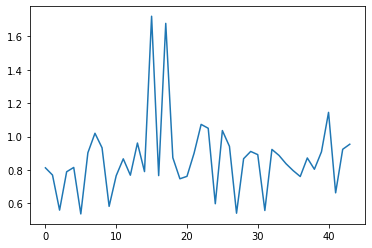

GM12878_counts-pos.pattern_38


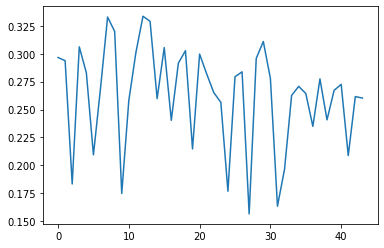

GM12878_counts-pos.pattern_23


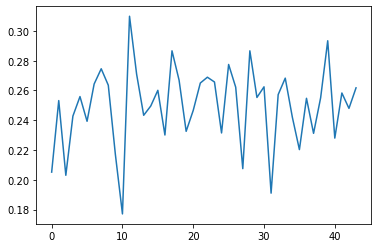

K562_profile-pos.pattern_49


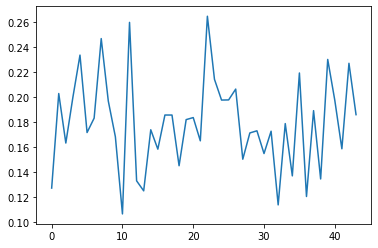

GM12878_profile-pos.pattern_25


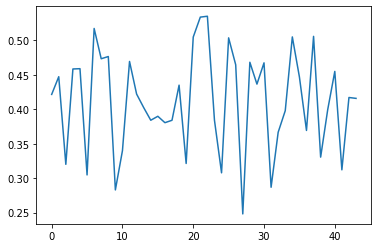

GM12878_profile-neg.pattern_48


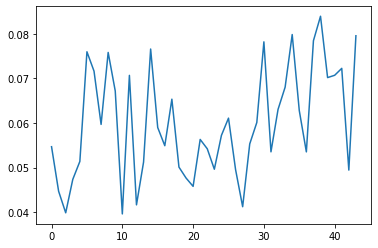

GM12878_profile-pos.pattern_54


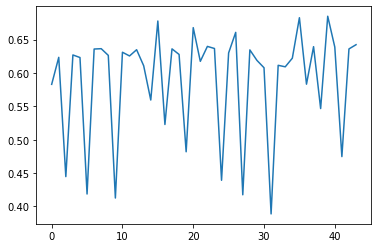

K562_profile-pos.pattern_24


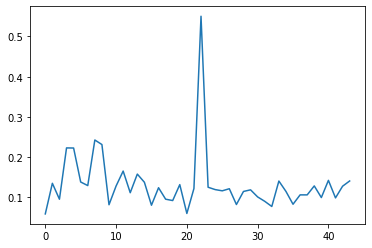

K562_profile-pos.pattern_48


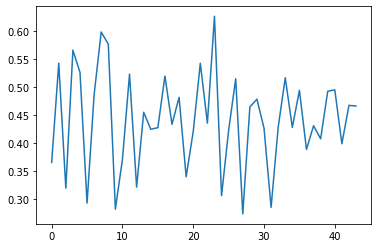

IMR90_profile-pos.pattern_56


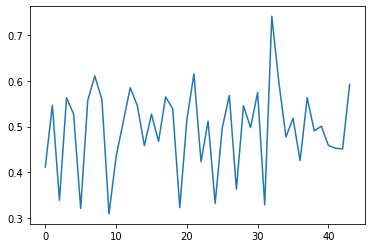

HEPG2_profile-pos.pattern_58


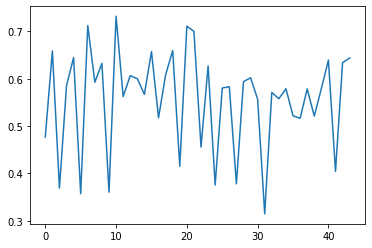

In [103]:
import matplotlib.pyplot as plt
soft_motifs = np.array(motif_name_new)[soft_syntax]
for keyd in soft_motifs[0:len(soft_motifs)]:
    print(keyd)
    combine_counts_values = loaded_data[keyd]['combine_counts'].values()
    flattened_values = np.concatenate([np.array(val).flatten() for val in combine_counts_values])
    joint = np.log(flattened_values) - np.log(loaded_data[keyd]['control']['counts'])
    plt.figure()
    plt.plot(joint)
    plt.show()
    #break

In [104]:
# soft_motifs = np.array(motif_names)[~(np.array(soft_syntax_motifs) & np.array(hard_syntax_motifs))]
# for keyd in soft_motifs[0:len(soft_motifs)]:
#     print(keyd)
#     combine_counts_values = loaded_data[keyd]['combine_counts'].values()
#     flattened_values = np.concatenate([np.array(val).flatten() for val in combine_counts_values])
#     joint = np.log(flattened_values) - np.log(loaded_data[keyd]['control']['counts'])
#     plt.figure()
#     plt.plot(joint)
#     plt.show()
#     #break

In [105]:
#sum(motif_table['posneg']=="neg")

In [106]:
#sum(motif_table['posneg']=="pos")